In [251]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os
import sys
from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

In [252]:
load_dotenv()
DATA_PATH_CLEANED = os.getenv("DATA_PATH_CLEANED")
pd.set_option('display.max_columns', None)

file_path = Path(DATA_PATH_CLEANED) / "feature_engineered_crime_data.parquet" 
df = pd.read_parquet(file_path)

In [253]:
project_root = Path().resolve().parent

sys.path.append(str(project_root))

from utils.visualization_utils import * 

set_plot_style()

In [254]:
df['reporting_delay_days'] = np.log1p(df['reporting_delay_days'])
df['crime_count'] = np.log1p(df['crime_count'])

## 1.Univariate Analysis

### 1.1 Numerical Features 
- victim_age
- hour_occurrence
- latitude
- longitude

#### Victim Age Distribution

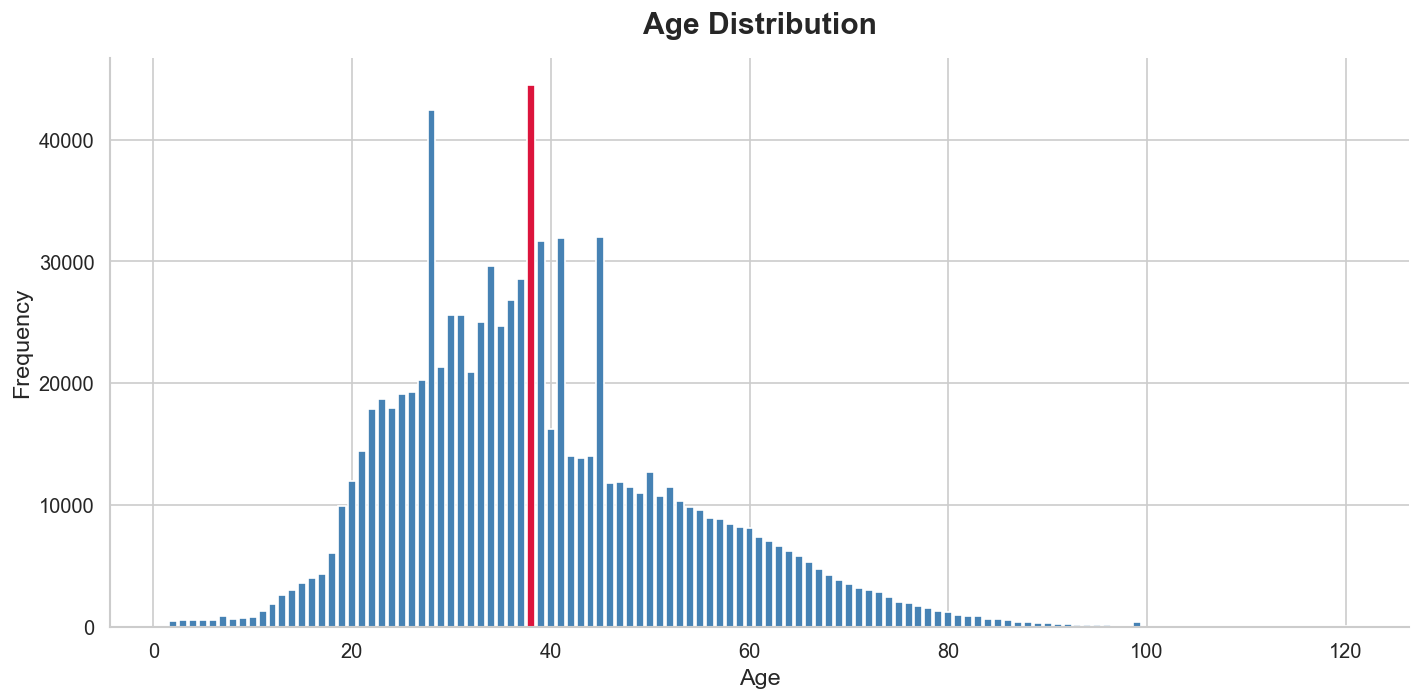

In [283]:
counts = df["victim_age"].value_counts().sort_index()
colors = get_highlight_colors(counts.values)

plt.bar(counts.index, counts.values, color=colors)  
setup_axes("Age Distribution", "Age", 'Frequency')
plt.tight_layout()
plt.show()

##### Observations: 
- Most victims are young-to-middle adults, peaking at age 40 (~125K).
- 70% of victims fall between 16 and 48 — crime risk drops sharply after 56.
- Almost no victims under 16 or above 88.

-----------------------------------------------------------------------

#### Hour Occurrence Distribution

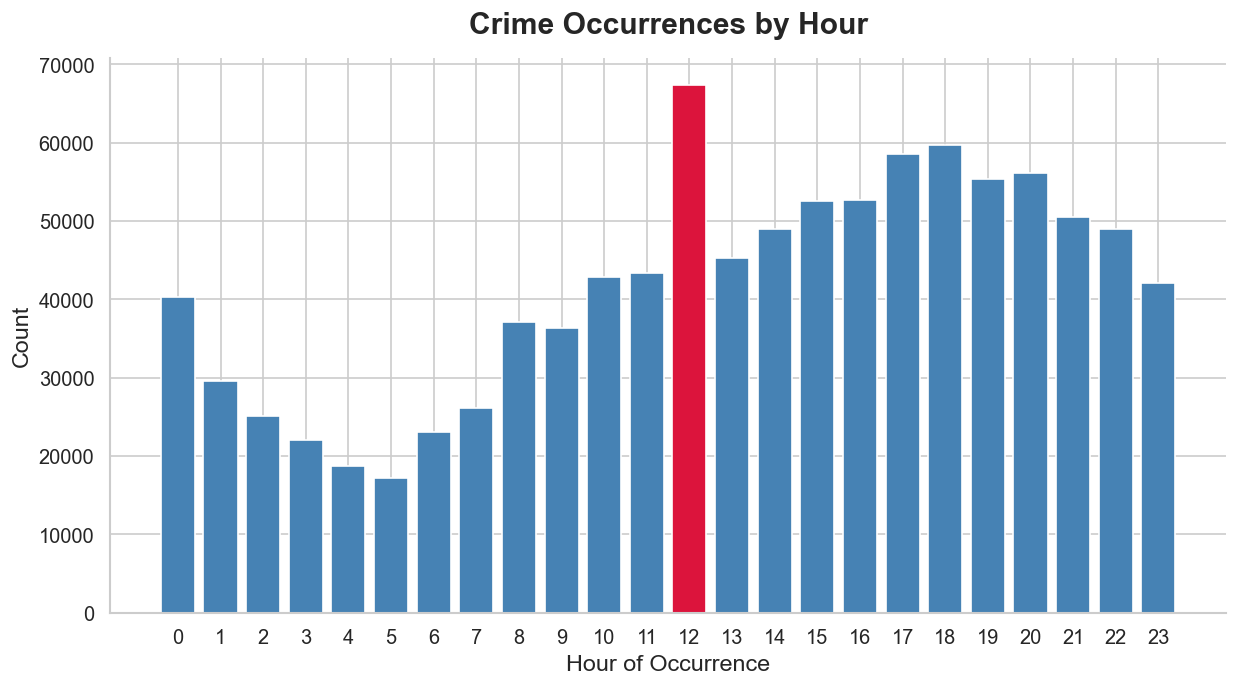

In [256]:
counts = df['hour_occurrence'].value_counts().sort_index()
colors = get_highlight_colors(counts.values)
plt.bar(counts.index, counts.values, color=colors)  
setup_axes("Crime Occurrences by Hour", "Hour of Occurrence", "Count")
plt.xticks(range(0, 24))
plt.show()

##### Observations: 
- Midday (12:00) is the most dangerous hour with ~68K crimes.
- Early morning (01:00–07:00) is the safest window.
- Crime builds steadily from 08:00 onward — this is a daytime phenomenon, not a nighttime one.
-----------------------------------

#### Is Night Occurrence 

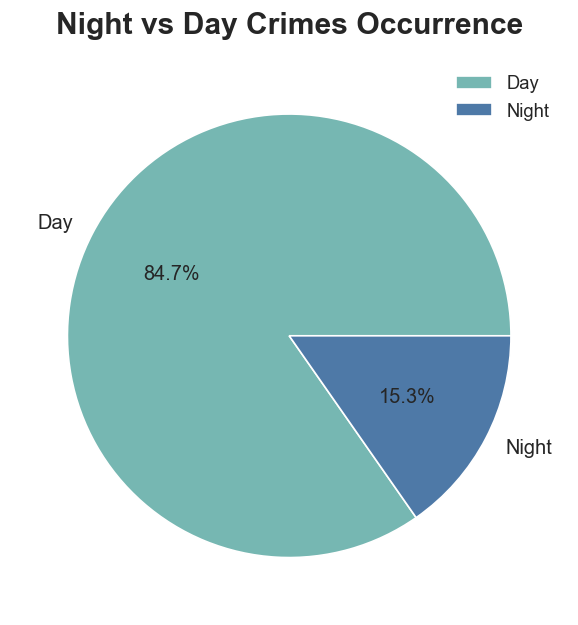

In [257]:
counts  = df['is_night_occurrence'].value_counts()

labels = ['Day', 'Night']
colors = get_highlight_colors(counts.values)
day_color = PALETTE[3]
night_color = PALETTE[0]
colors = [day_color, night_color]
plt.pie(
    x=counts,
    labels = labels,
    autopct='%1.1f%%',
    colors = colors,
)
setup_axes("Night vs Day Crimes Occurrence")
plt.legend()
plt.show()

##### Observations: 
 - Most crimes happen during the day, consistent with the hour distribution above.

 ------------------------

#### Longitude vs Latitude

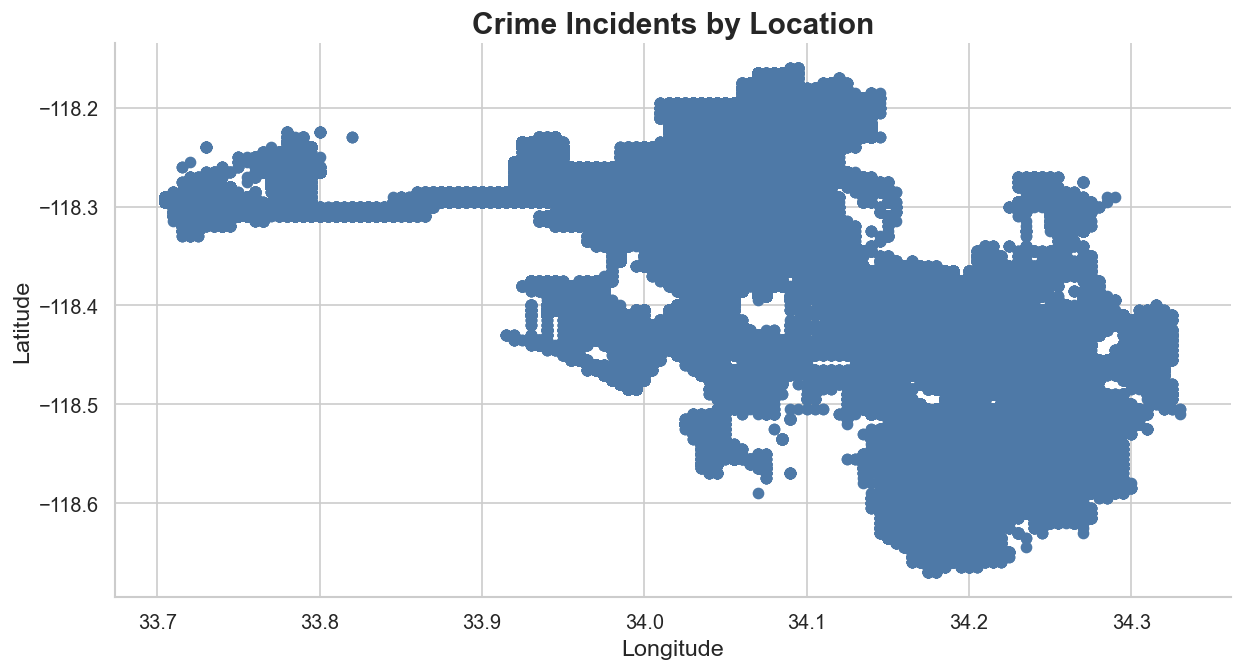

In [258]:
plt.scatter(df['lat_bin'], df['lon_bin']) 
plt.title('Crime Incidents by Location')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

##### Observations: 
- The densest crime zone sits in the lower-right cluster (34.1–34.3, -118.5 to -118.6).
- A separated western arm suggests a distinct geographic hotspot worth investigating.

----------------

#### Reporting Delay Days 

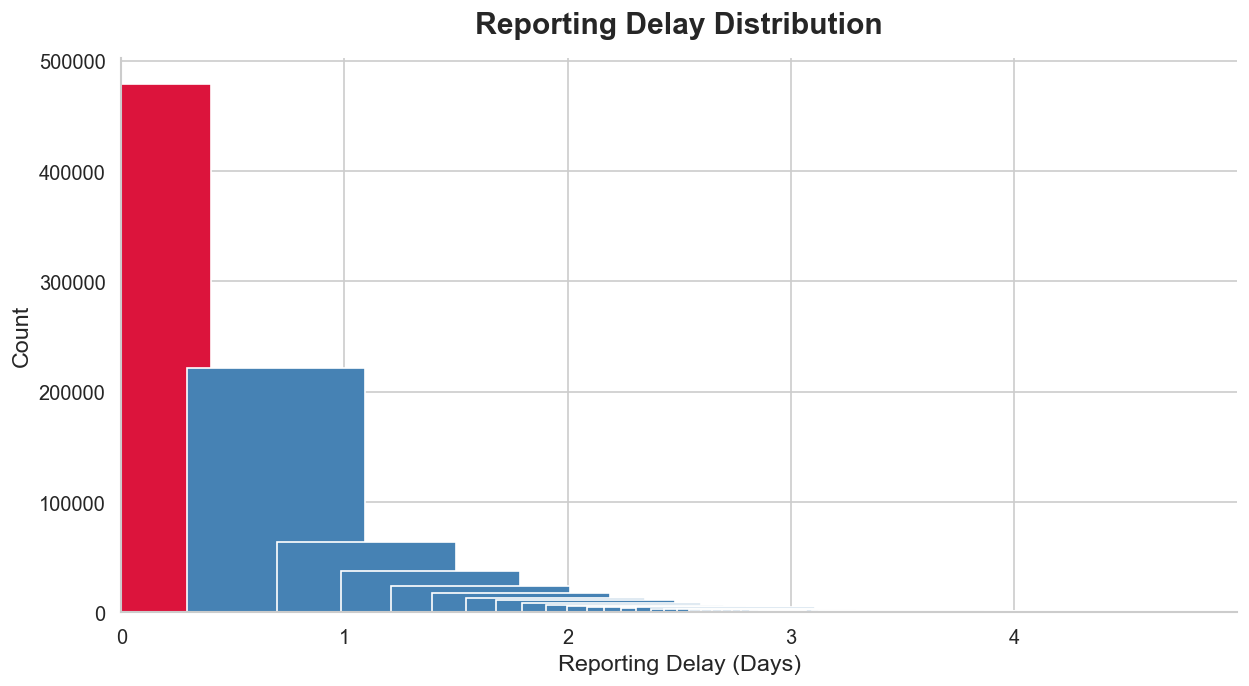

In [285]:
counts = df['reporting_delay_days'].value_counts().sort_index()
colors = get_highlight_colors(counts.values)
plt.bar(counts.index, counts.values, color=colors)  
setup_axes("Reporting Delay Distribution", "Reporting Delay (Days)", "Count")
plt.xlim(0, 5)
plt.xticks(range(0, 5, 1))
plt.show()

##### Observations: 
- Half of all crimes are reported same-day.
- Reports drop sharply after day 2 — delayed reporting beyond a week is rare.

-------------------------

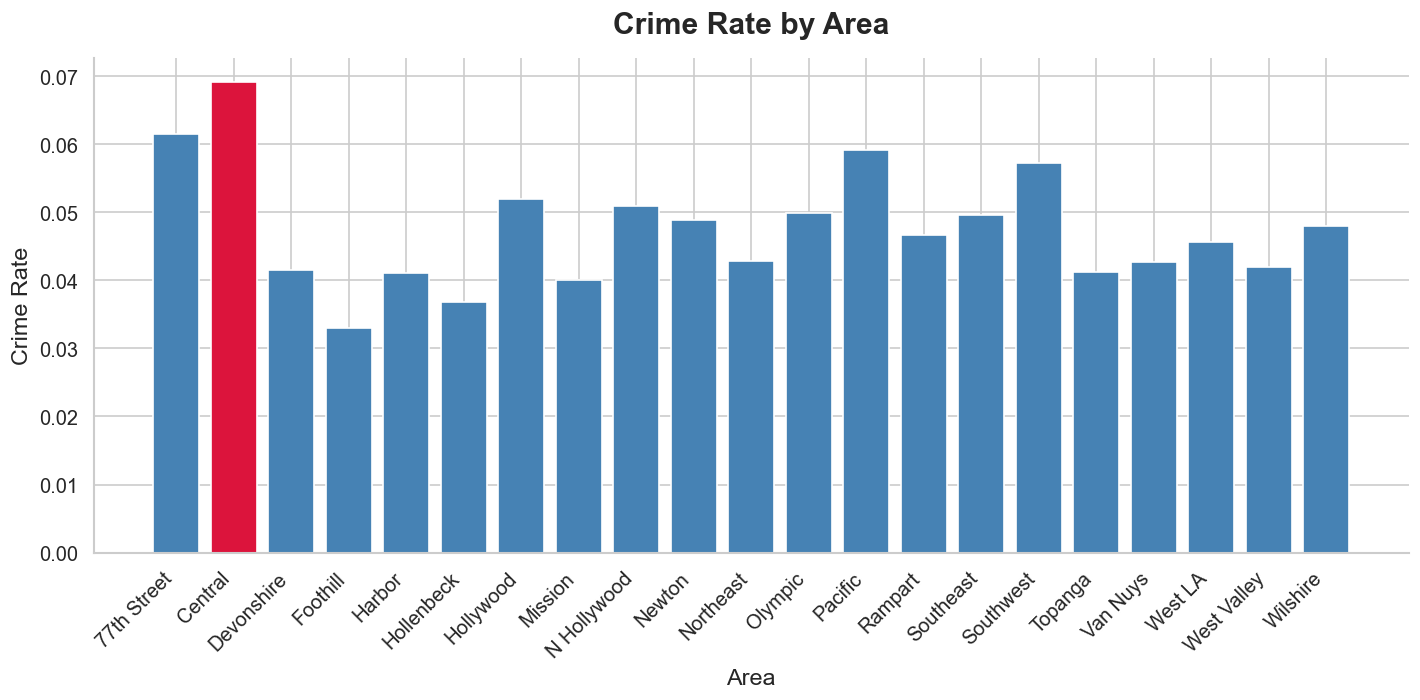

In [260]:
area_stats = df.groupby('area_name')['area_crime_share'].mean()
colors = get_highlight_colors(area_stats.values)

plt.bar(area_stats.index, area_stats.values, color=colors) 
plt.xticks(rotation=45, ha="right")
setup_axes("Crime Rate by Area", "Area", "Crime Rate")
plt.tight_layout()
plt.show()

##### Obsrevations: 
- Central leads with ~0.068 share — the clear outlier.
- 19 of 21 areas cluster tightly above 0.04, meaning crime is spread fairly evenly across the city.

------------------

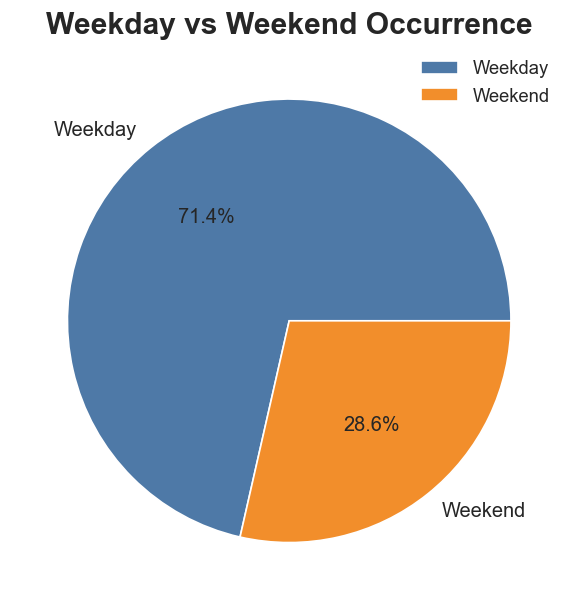

In [286]:
counts = df['is_weekend_occurrence'].value_counts()
is_weekend_map = {
    0: 'Weekday',
    1: 'Weekend'
}
plt.pie(
    x=counts,
    labels= counts.index.map(is_weekend_map), 
    autopct='%1.1f%%'
)
plt.title("Weekday vs Weekend Occurrence")
plt.legend()
plt.show()

##### Observations: 
- 71.4% of crimes happen on weekdays — crime follows the working week.

-------------------

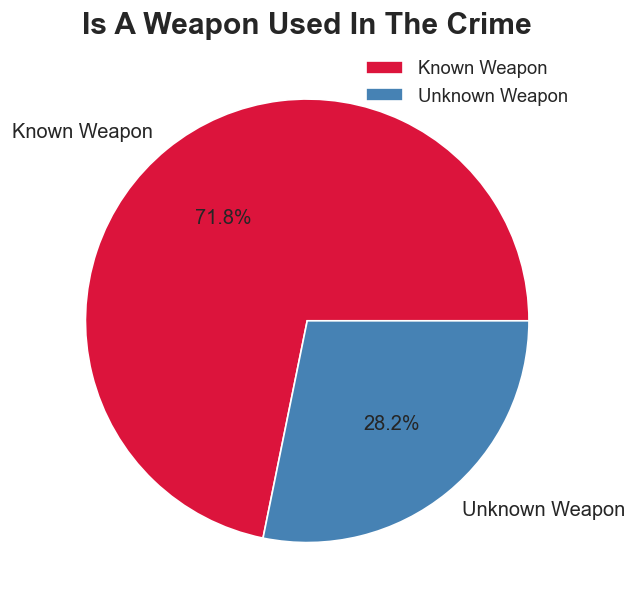

In [288]:
counts = df['weapon_flag'].value_counts() 
df[~df['weapon_description'].str.contains('unknown', case=False, na=False)]['weapon_description'].unique()

weapon_flag_map = {
    0: "Unknown Weapon",
    1: "Known Weapon"
}

plt.pie(
    x=counts,
    autopct='%1.1f%%',
    labels = counts.index.map(weapon_flag_map), 
    colors = colors
)
plt.title("Is A Weapon Used In The Crime")
plt.legend()
plt.show()

##### Observations: 
- 71.8% of crimes involve a known weapon.
- Only 28.2% have unknown or no weapon recorded.

--------------------

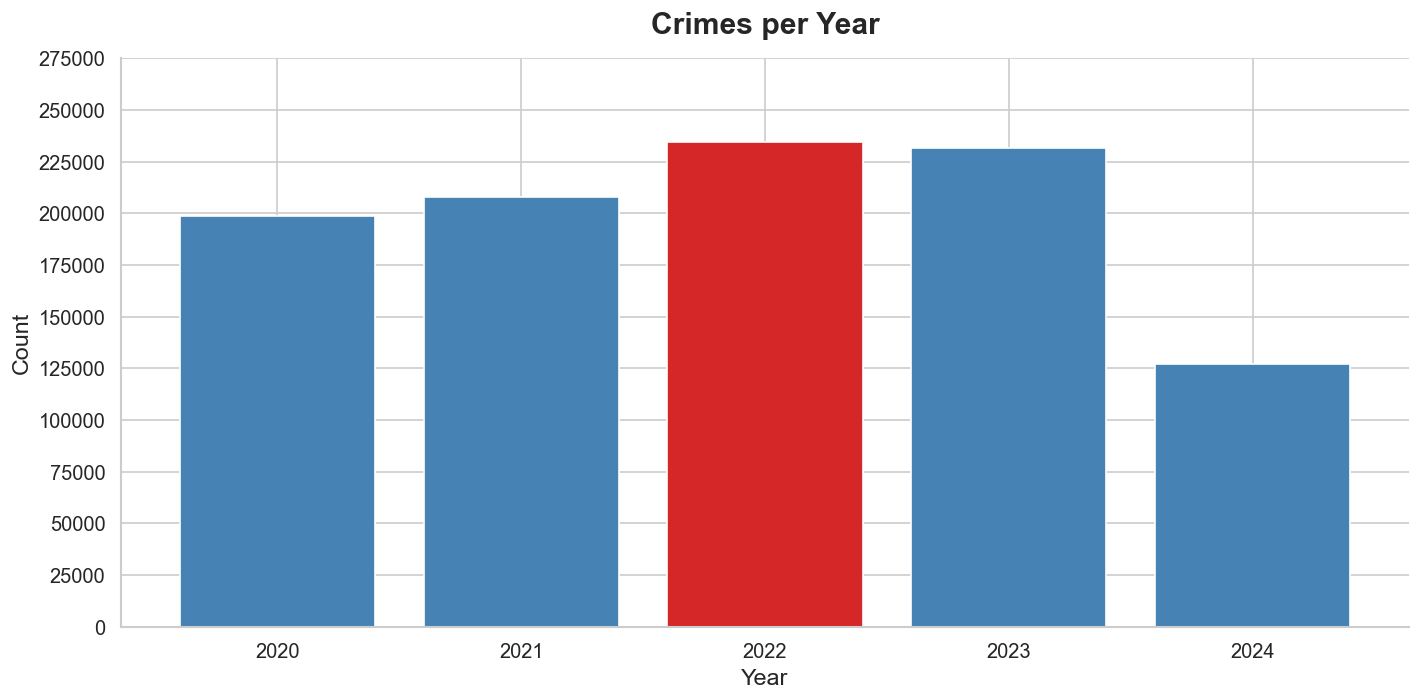

In [263]:
# Line plots for year 

year_counts = df['year_occurrence'].value_counts().sort_index()
colors = get_highlight_colors(year_counts.values, highlight=WARNING_COLOR)
plt.bar(year_counts.index, year_counts.values, color=colors) 
plt.yticks(range(0, 300000, 25000))
setup_axes("Crimes per Year", "Year", "Count")
plt.tight_layout()
plt.show()

##### Observations: 
- 2022 was the peak year (~225K crimes).
- 2023 was close behind with a slight drop.
- 2024 is the lowest (~125K) — likely incomplete data, not a real decline.

--------------------

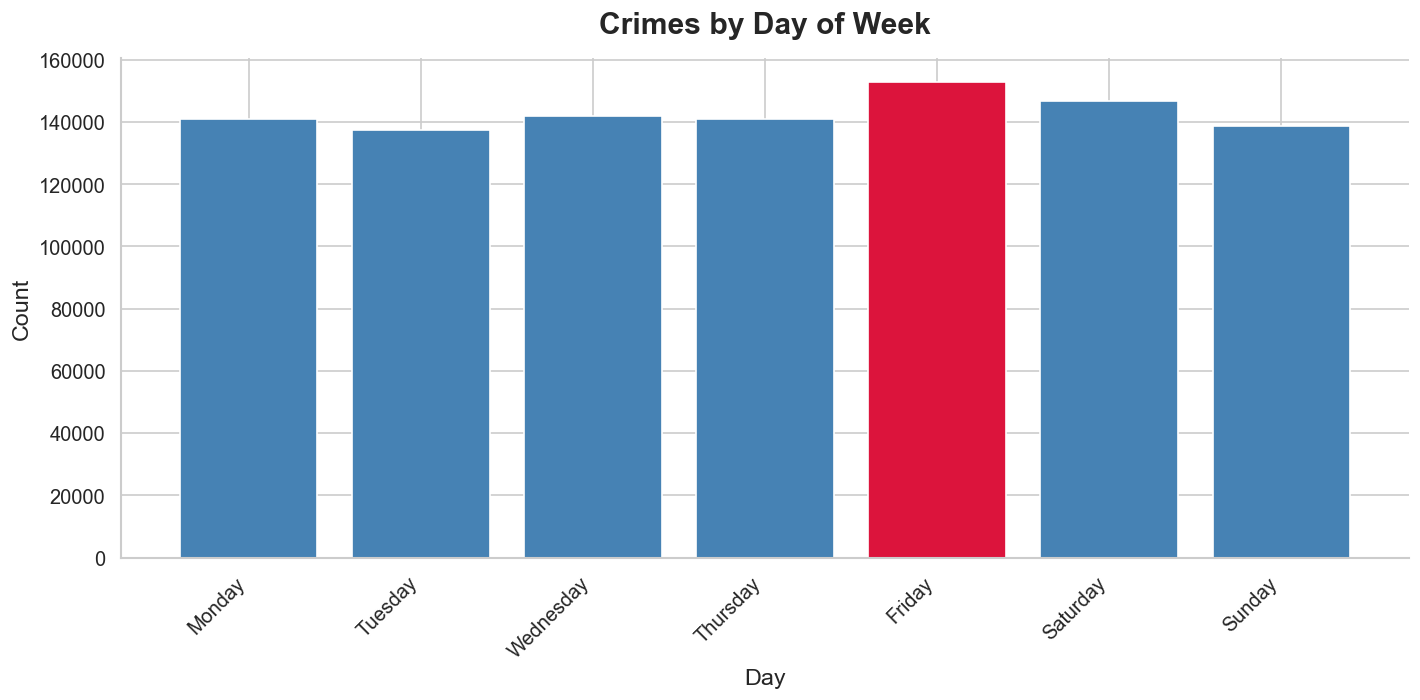

In [264]:
counts = df['day_of_week_num'].value_counts().sort_index()
colors = get_highlight_colors(counts.values)
day_of_week_map = {0: "Monday", 1: "Tuesday", 2: "Wednesday", 3: "Thursday", 4: "Friday", 5: "Saturday", 6: "Sunday"}

plt.bar(counts.index, counts.values, color=colors) 
plt.xticks(ticks=counts.index, labels=[day_of_week_map[i] for i in counts.index], rotation=45, ha="right")
setup_axes("Crimes by Day of Week", "Day", "Count")
plt.tight_layout()
plt.show()

##### Observations: 
- Friday sees the most crimes (~150K), Tuesday the least (~138K).
- The difference across days is small — no single day stands out dramatically.

------------------------------------

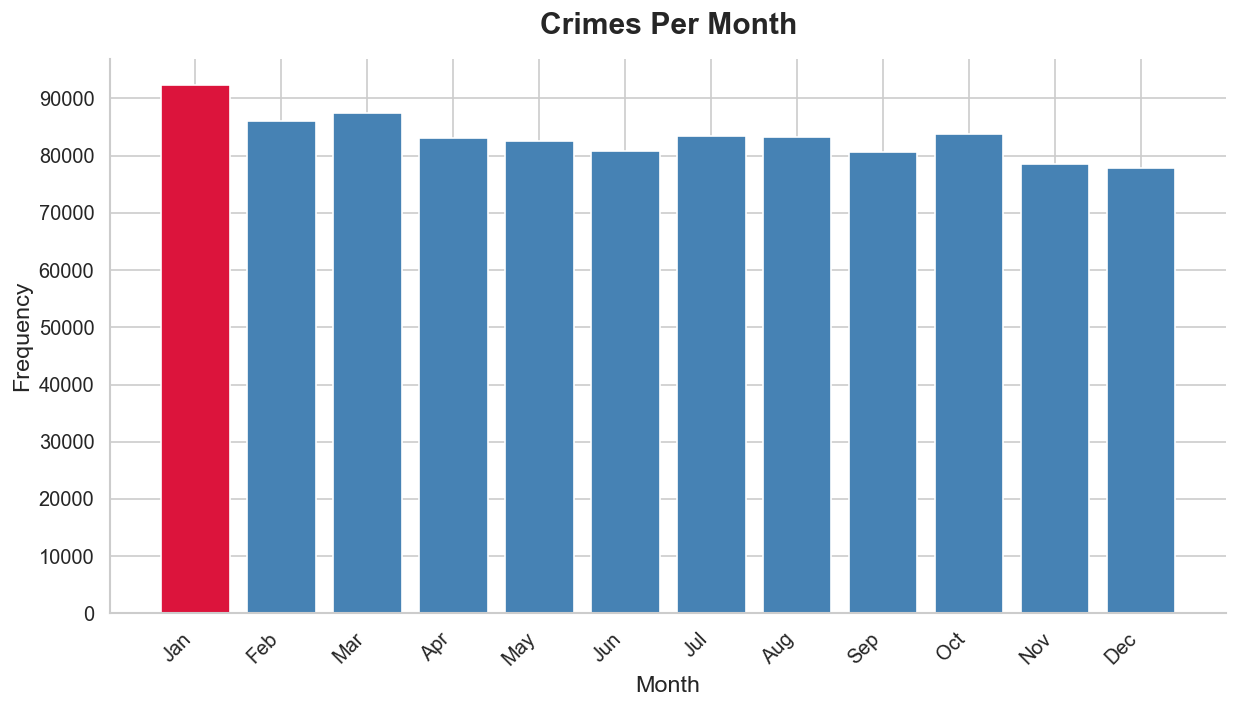

In [290]:
months_counts = df['month_occurrence'].value_counts()
colors = colors = get_highlight_colors(months_counts.values)

months_map = {1 : "Jan",2 : "Feb",3 : "Mar",4 : "Apr",5 : "May",6 : "Jun",7 : "Jul",8 : "Aug",9 : "Sep",10 : "Oct",11 : "Nov",12 : "Dec"}

plt.bar(
    months_counts.index, 
    months_counts.values, 
    color= colors,
)
setup_axes("Crimes Per Month", "Month", "Frequency")
plt.xticks(ticks=months_counts.index, labels=[months_map[i] for i in months_counts.index], rotation=45, ha="right")
plt.yticks(range(0, 100000, 10000))
plt.show()

##### Observations: 
- January leads with ~90K crimes, March follows at ~86K.
- The remaining months cluster around 80K — no strong seasonal pattern.

-----------

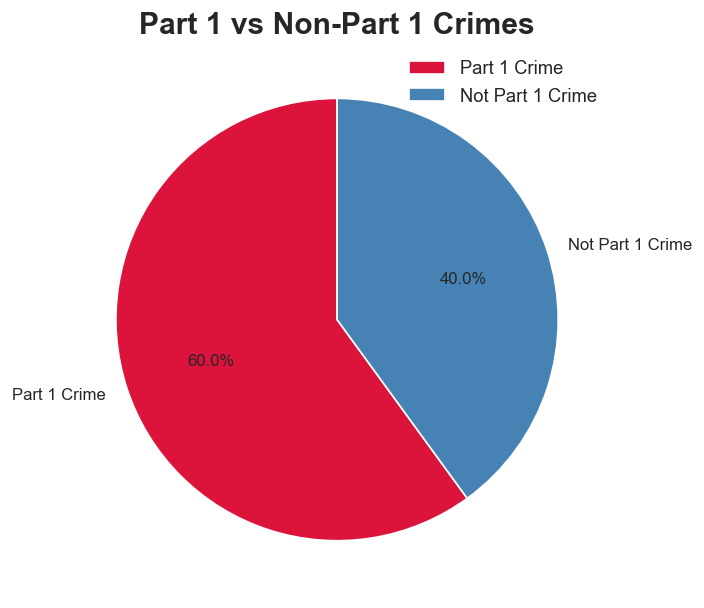

In [291]:
crime_part_counts = df['crime_part'].value_counts()

labels = crime_part_counts.index.map({
    1: "Part 1 Crime",
    0: "Not Part 1 Crime"
})

# Plot
plt.figure(figsize=(6, 6))

plt.pie(
    x=crime_part_counts.values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 10}
)

plt.title("Part 1 vs Non-Part 1 Crimes")
plt.legend(labels, loc="best")
plt.tight_layout()

plt.show()

##### Observations:
- 60% are Part 1 crimes — the dataset skews toward serious offenses.
- Non-Part 1 crimes still make up a substantial 40%.

--------------------------

In [269]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    if n_outliers > 0:
        print(f"{col}: {n_outliers:,} outliers")

victim_age: 14,599 outliers
latitude: 30,726 outliers
longitude: 26 outliers
reporting_delay_days: 91,742 outliers
is_night_occurrence: 152,929 outliers
area_crime_share: 69,168 outliers
lat_bin: 35,118 outliers
crime_count: 17,188 outliers


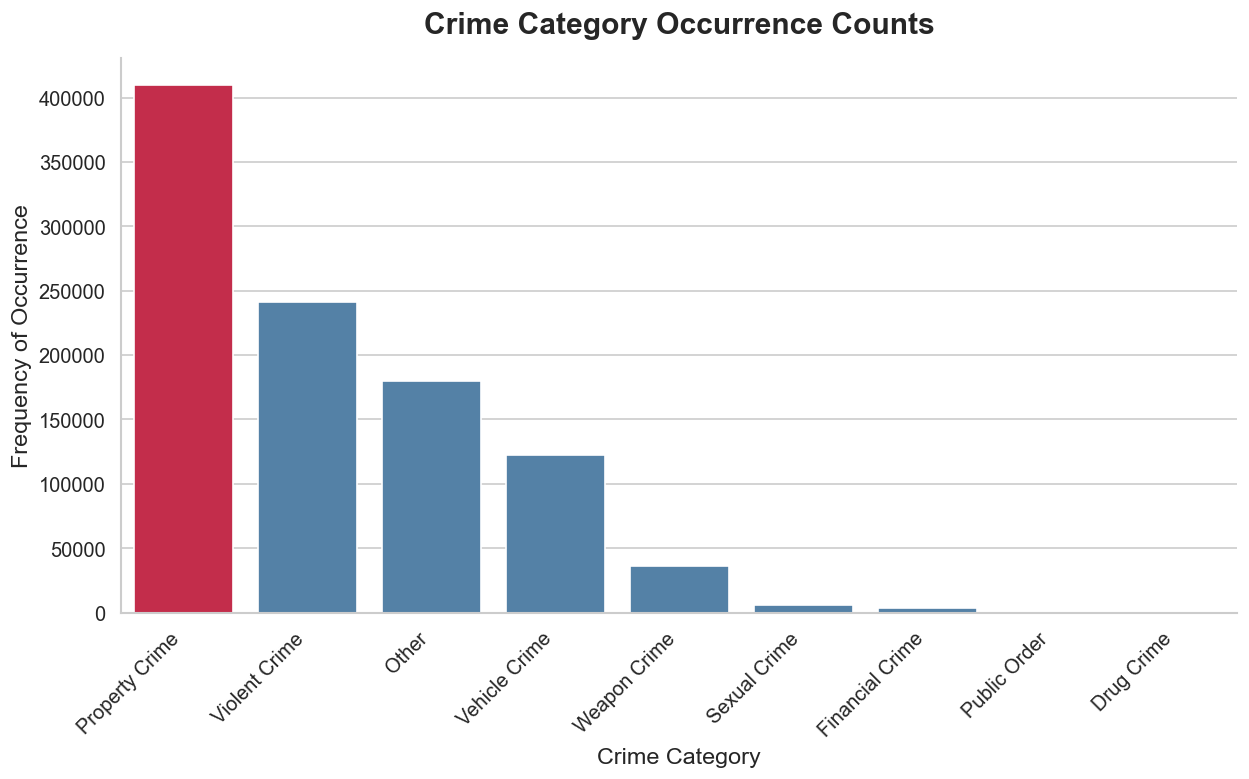

In [270]:
crime_counts = df['crime_category'].value_counts()
colors = get_highlight_colors(crime_counts.values)

sns.barplot(
    x=crime_counts.index,
    y=crime_counts.values,
    palette=colors
)

setup_axes(
    "Crime Category Occurrence Counts",
    "Crime Category",
    "Frequency of Occurrence"
)

plt.xticks(rotation=45, ha='right')
plt.show()

##### Observations: 
- Property Crime dominates at ~410K — 1.7× Violent Crime and 3.4× Vehicle Crime.
- Three tiers are visible: Property/Violent/Other on top, Vehicle in the middle, everything else near zero.
- The bottom five categories combined are smaller than Vehicle Crime alone.

--------------

#### Victim Descent

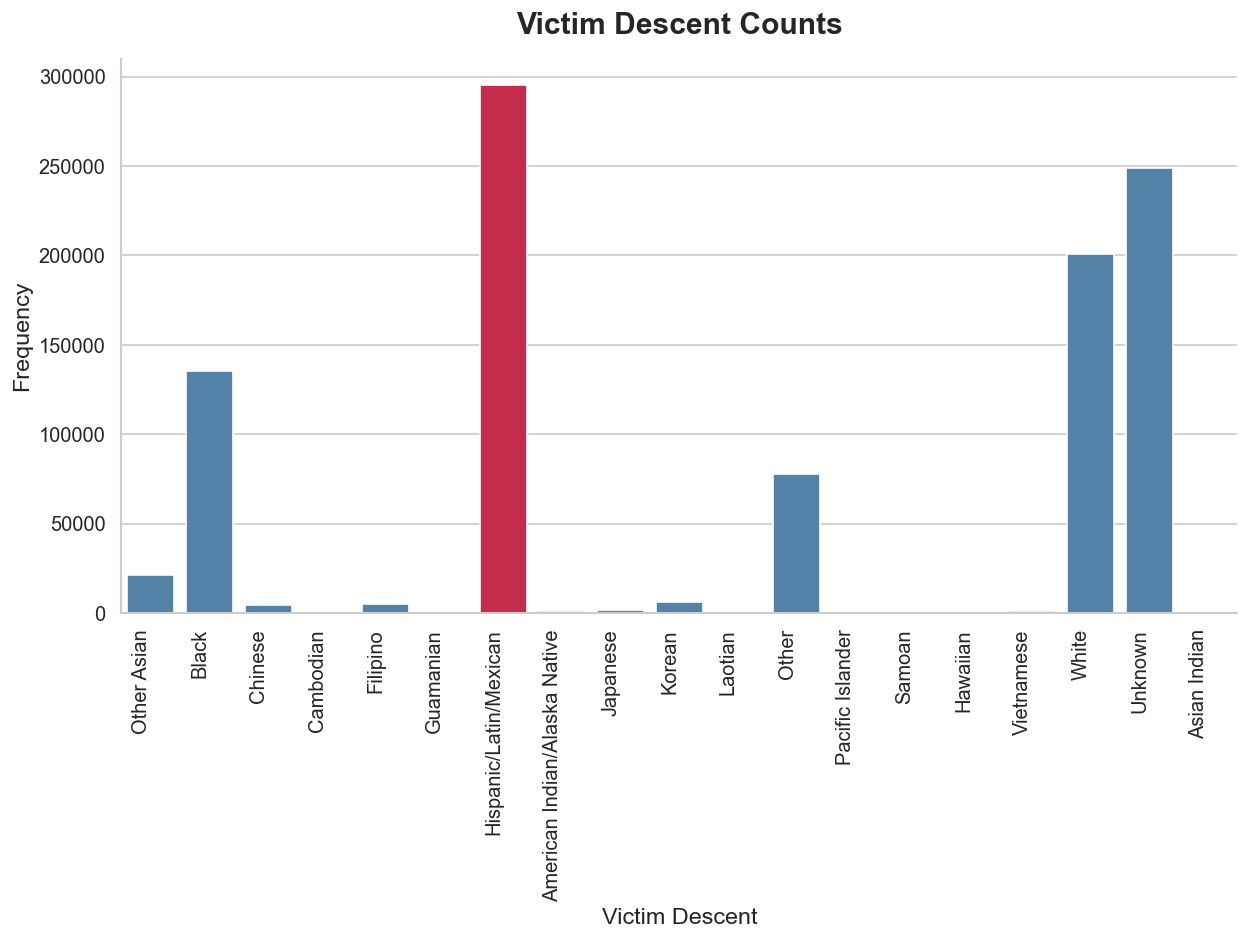

In [295]:
victim_descent_counts = df['victim_descent'].value_counts().sort_index()
color = get_highlight_colors(victim_descent_counts.values)
victim_descent_map = {
    "A": "Other Asian",
    "B": "Black",
    "C": "Chinese",
    "D": "Cambodian",
    "F": "Filipino",
    "G": "Guamanian",
    "H": "Hispanic/Latin/Mexican",
    "I": "American Indian/Alaska Native",
    "J": "Japanese",
    "K": "Korean",
    "L": "Laotian",
    "O": "Other",
    "P": "Pacific Islander",
    "S": "Samoan",
    "U": "Hawaiian",
    "V": "Vietnamese",
    "W": "White",
    "X": "Unknown",
    "Z": "Asian Indian"
}
sns.barplot(
    x=victim_descent_counts.index,
    y=victim_descent_counts.values,
    palette=color
)
setup_axes(
    "Victim Descent Counts",
    "Victim Descent",
    "Frequency"
)
plt.xticks(
    ticks=victim_descent_counts.index, 
    labels=[victim_descent_map[i] for i in victim_descent_counts.index],
    rotation=90, 
    ha="right")
plt.show()

##### Observations: 
- Hispanic/Latin/Mexican is the largest group (~295K), followed by Unknown (~248K) and White (~200K).
- Over half the descent categories have fewer than 5K victims each — a long sparse tail.
- Unknown at ~248K means 1 in 5 records has no descent info — a meaningful data quality gap.

----------------------

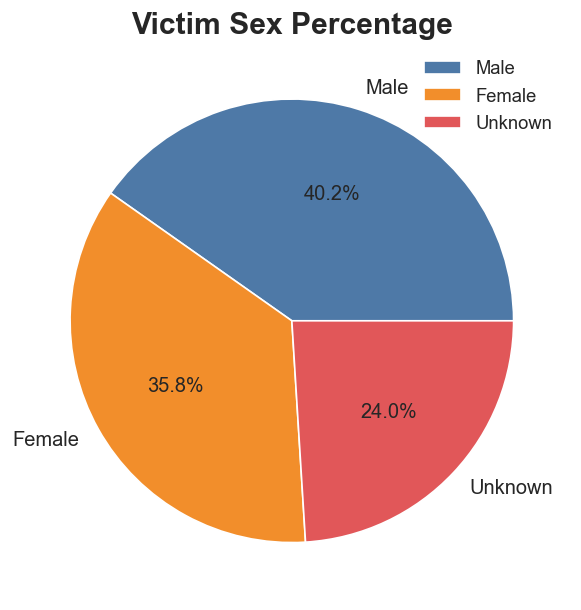

In [273]:
sex_counts = df['victim_sex'].value_counts()
sex_map = {
    'M' : "Male",
    'F' : "Female",
    'Unknown':"Unknown"
}
plt.pie(
    x=sex_counts,
    labels=sex_counts.index.map(sex_map),
    autopct='%1.1f%%',
)
plt.title("Victim Sex Percentage")
plt.legend()
plt.show()

##### Observations: 
- Males are 40.2%, females 35.8%, unknown 24%.
- The high unknown rate mirrors the descent field — reporting quality is inconsistent.

-------------------

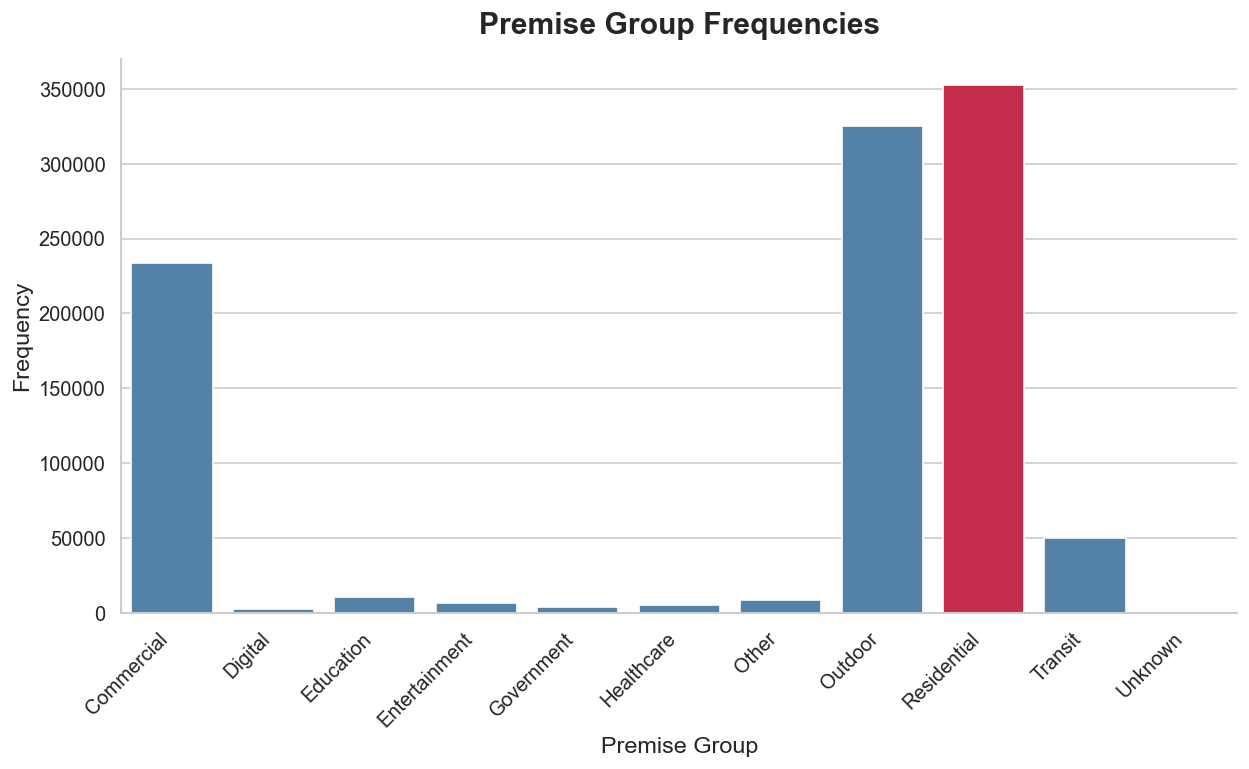

In [274]:
premise_counts = df['premise_group'].value_counts().sort_index()
color = get_highlight_colors(premise_counts.values)
sns.barplot(
    x=premise_counts.index,
    y=premise_counts.values,
    palette=color
)
plt.xticks(rotation=45, ha='right')
setup_axes(
    "Premise Group Frequencies",
    "Premise Group",
    "Frequency"
)
plt.show()

##### Observations: 
- Residential (~352K) and Outdoor (~324K) account for most crimes, followed by Commercial.
- These three combined exceed 900K — the remaining eight groups total under 100K.
- Unknown premise is nearly zero — this field is well recorded.

-----------------------

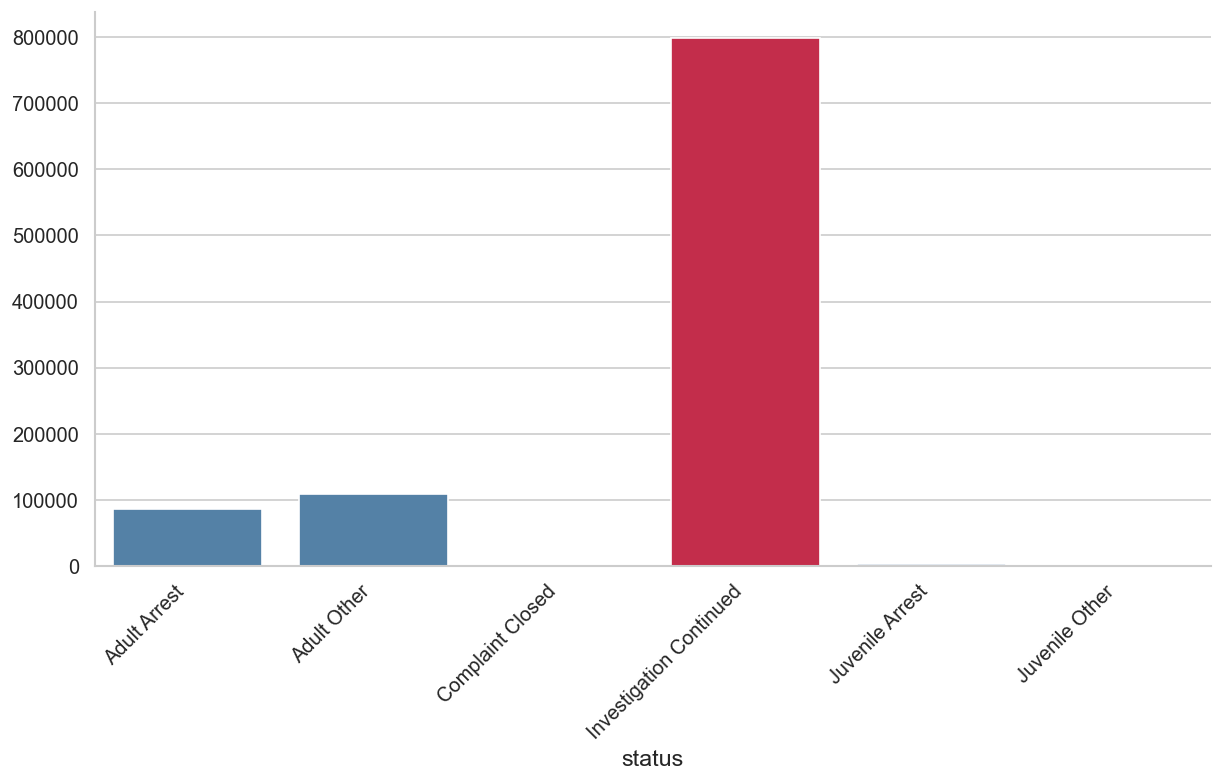

In [303]:
court_status_map = {
    "IC": "Investigation Continued",
    "AO": "Adult Other",
    "AA": "Adult Arrest",
    "JA": "Juvenile Arrest",
    "JO": "Juvenile Other",
    "CC": "Complaint Closed"
}

court_status_counts = df['status'].value_counts().sort_index()
sns.barplot(
    x=court_status_counts.index,
    y=court_status_counts.values,
    palette=get_highlight_colors(court_status_counts.values)
)
plt.xticks(
    ticks=range(len(court_status_counts)),
    labels=court_status_counts.index.map(court_status_map),
    rotation=45,
    ha='right'
)

plt.show()

##### Observations: 
- Investigation Continued dominates with ~800K cases — 80% of all records are still open.
- Juvenile Arrest and Juvenile Other are completely absent — likely filtered out or stored separately, worth investigating before modeling.
- Only Adult Arrest (~85K) and Adult Other (~105K) represent resolved cases — less than 20% of the dataset.
- A binary Open vs. Closed target is more practical than multiclass given this imbalance.

In [277]:
df['status'].value_counts(normalize=True)

status
IC    0.798359
AO    0.109681
AA    0.086813
JA    0.003268
JO    0.001873
CC    0.000006
Name: proportion, dtype: float64